In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#LOAD DATASET
df = pd.read_csv("retail_sales_dataset.csv")

# Display first 5 rows
print(df.head())


   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


**Check missing values and Convert Date column to datetime**


In [ ]:
print("\nMissing Values:\n", df.isnull().sum())
df['Date'] = pd.to_datetime(df['Date'])


Missing Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


**Descriptive Statistics**

In [ ]:
print("\nDescriptive Statistics:\n")
print(df.describe())
print("\nMean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])


Descriptive Statistics:

       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.0

**Time Series Analysis**

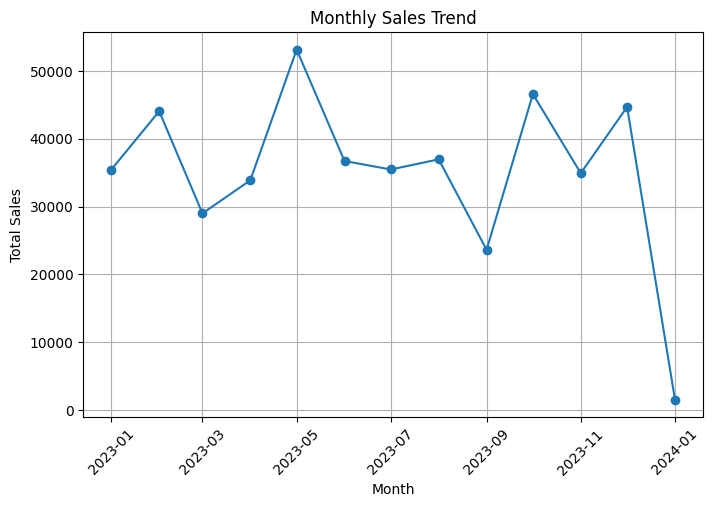

In [ ]:

# Monthly Sales
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

# Convert index to timestamp
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot Monthly Sales Trend
plt.figure(figsize=(8,5))
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()


**Customer Analysis**

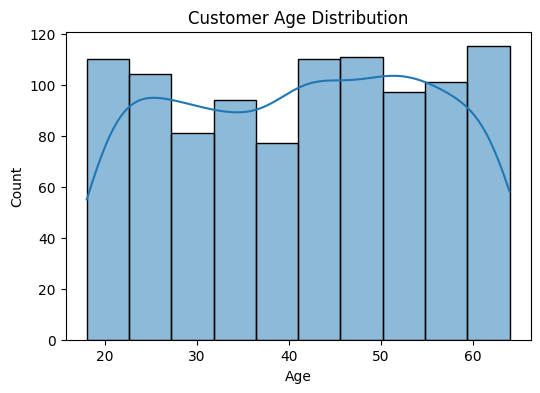

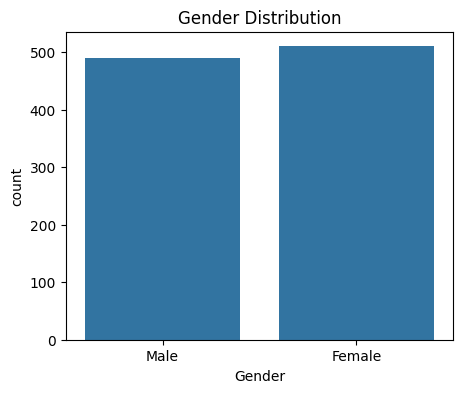

In [ ]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.show()

# Gender Distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

**Product Analysis**

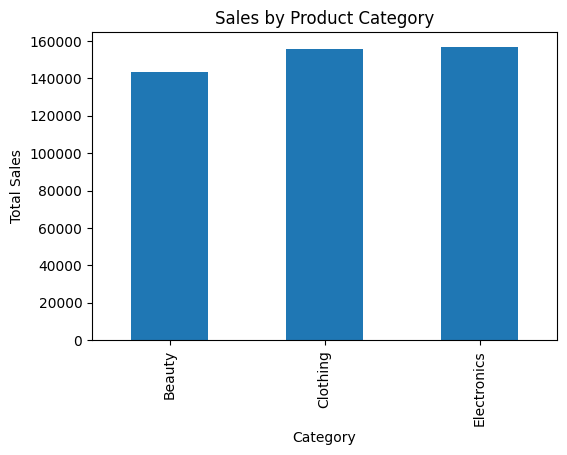

In [ ]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
plt.figure(figsize=(6,4))
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()


**Correlation Heatmap**

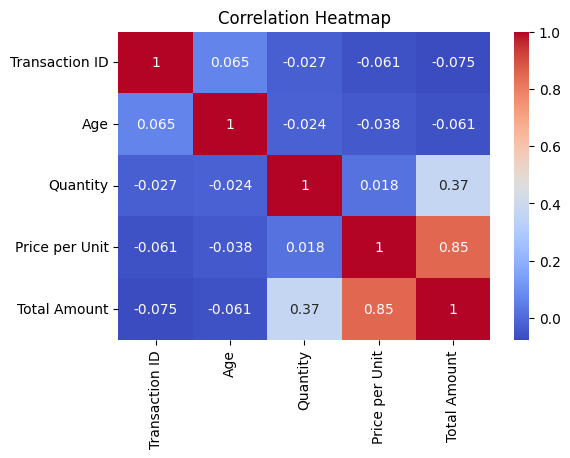

In [ ]:

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Top Customers**

In [ ]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Customers:\n", top_customers)



Top 5 Customers:
 Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
Name: Total Amount, dtype: int64


**Insights**

In [ ]:
print("\nKey Insights:")
print("- Sales show monthly variation (seasonal trend).")
print("- Most customers buy 1–4 products.")
print("- Middle-aged customers dominate purchases.")
print("- Few customers contribute to high revenue.")


Key Insights:
- Sales show monthly variation (seasonal trend).
- Most customers buy 1–4 products.
- Middle-aged customers dominate purchases.
- Few customers contribute to high revenue.
